# Time Series Analysis

## 1. Introduction to Time Series Data

Time series data is data collected over a sequence of time intervals such as daily, weekly, monthly, or yearly observations.

### Examples of Time Series Data
- Stock market prices
- Sales records
- Weather data
- Temperature readings
- Website traffic

### Characteristics of Time Series Data

1. **Chronological Order**  
   Data points are arranged according to time from past to present.

2. **Sequential Data**  
   Each observation depends on the sequence in which it occurs.

3. **Temporal Components**  
   Time series data often contains patterns such as trends, seasonality, and cycles.

4. **Constant Frequency**  
   Data is usually collected at regular intervals like hourly, daily, or monthly.

5. **Dynamic Nature**  
   Values change over time due to internal or external factors.

---

# 2. Time Series Analysis

Time series analysis is a statistical technique used to extract meaningful insights, identify patterns, and understand trends from time-based data.

It helps in:
- Understanding past behavior
- Forecasting future values
- Detecting trends and seasonal patterns

---

# 3. Time Series Decomposition

Time series decomposition breaks data into multiple components for better analysis.

## Components of Time Series

1. **Trend**  
   The long-term upward or downward movement in data.

2. **Seasonality**  
   Repeating patterns that occur at fixed and regular intervals.

3. **Cyclic Component**  
   Repeating patterns that occur over irregular time periods.

   - **Economic Cycles**  
     Changes caused by inflation, recession, or economic growth.

   - **Business Cycles**  
     Variations in business performance due to market conditions.

4. **Noise (Irregular Component)**  
   Random fluctuations or sudden spikes that cannot be predicted.

---

# 4. Types of Decomposition

## Additive Decomposition

Used when seasonal variations remain relatively constant over time.

$y_t = T_t + S_t + E_t$



Where:
- \( y_t \) = Observed value
- \( T_t \) = Trend component
- \( S_t \) = Seasonal component
- \( E_t \) = Error/Noise component

---

## Multiplicative Decomposition

Used when seasonal variations increase or decrease proportionally with the trend.

$y_t = T_t \times S_t \times E_t$
Where:
- \( y_t \) = Observed value
- \( T_t \) = Trend component
- \( S_t \) = Seasonal component
- \( E_t \) = Error/Noise component

![](./images/img1.png)

In [41]:
#Imports
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

In [9]:
import yfinance as yf

stock_data = yf.download("AAPL", start="2024-01-01", end="2024-08-01")
stock_data.columns = stock_data.columns.droplevel(1)

print(stock_data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Date                                                                
2024-01-02  183.562195  186.330858  181.831782  185.055288  82488700
2024-01-03  182.187759  183.799520  181.376930  182.158096  58414500
2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
2024-01-05  179.152100  180.714417  178.153410  179.953046  62379700
2024-01-08  183.483063  183.522623  179.468508  180.051901  59144500


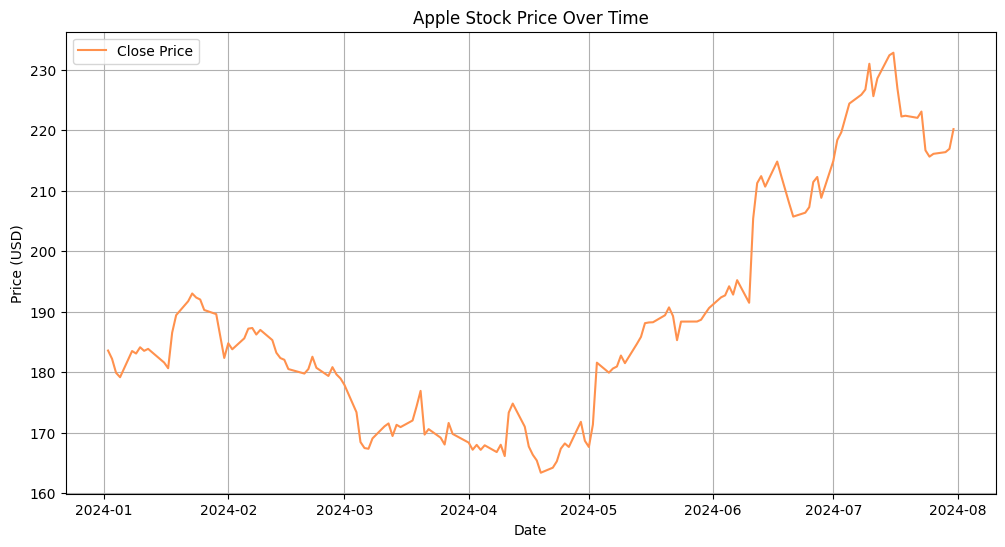

In [10]:
plt.figure(figsize=(12,6))
plt.plot(stock_data.index, stock_data["Close"], label = "Close Price", color="#FF914D")
plt.title("Apple Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Decomposition Using Classic Method

Classical decomposition is a traditional approach where a time series is split into its main components:
- Trend
- Seasonality
- Residual (Noise)

It assumes that these components combine in either an additive or multiplicative form.

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_additive = seasonal_decompose(stock_data['Close'], model="additive", period=30)

In [18]:
trend_additive = decomposition_additive.trend
seasonal_additive = decomposition_additive.seasonal
residual_Additive = decomposition_additive.resid

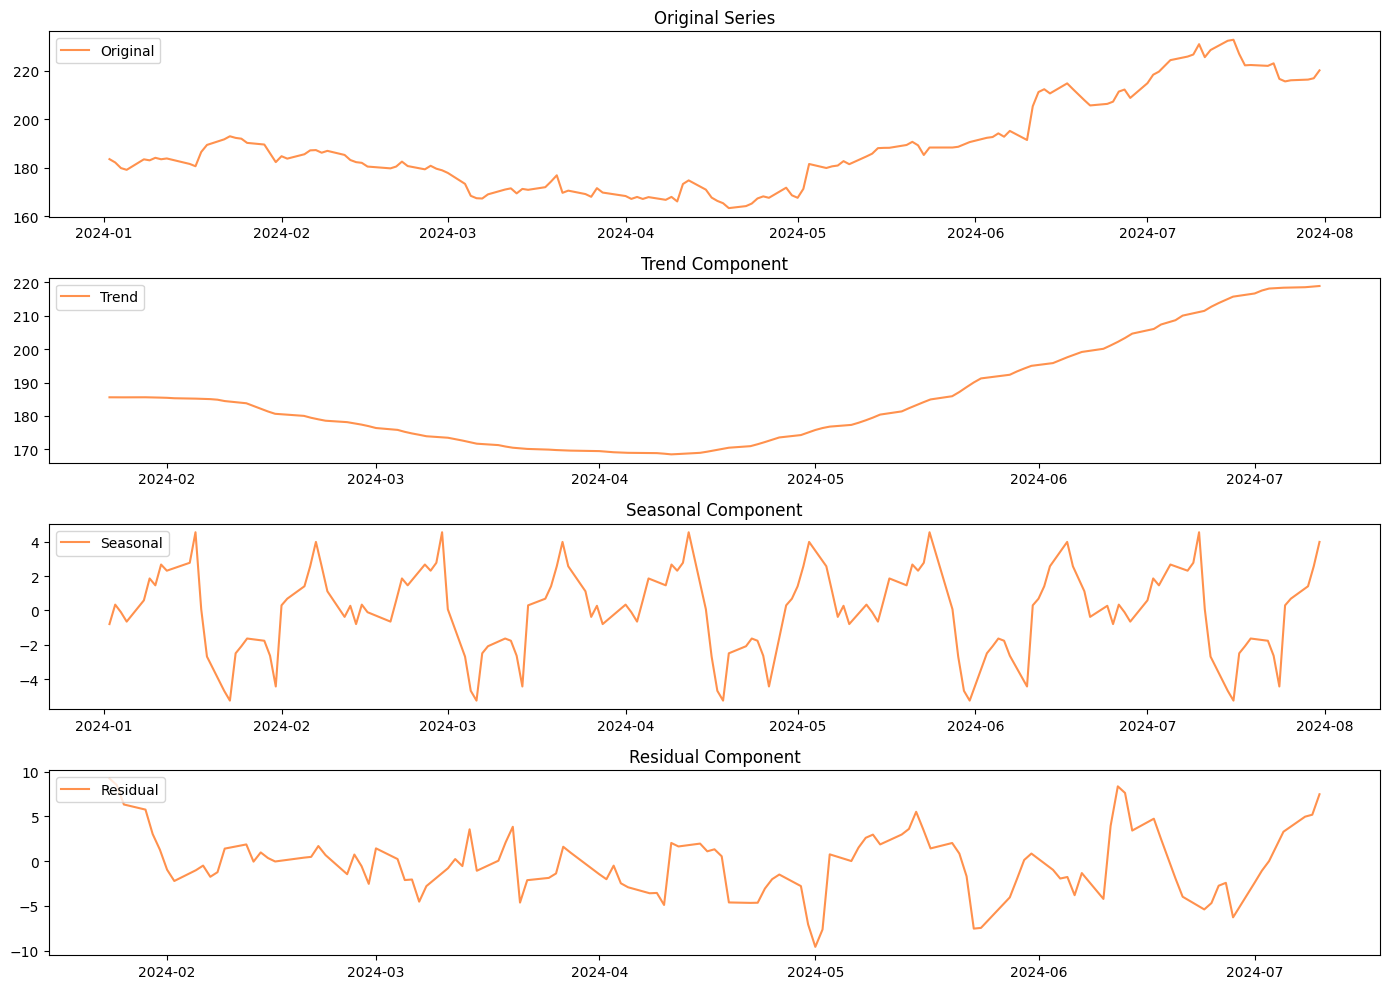

In [19]:
fig, ax = plt.subplots(4, 1, figsize=(14, 10))

# 1. Original series
ax[0].plot(stock_data['Close'], label="Original", color="#FF914D")
ax[0].legend(loc='upper left')
ax[0].set_title("Original Series")

# 2. Trend
ax[1].plot(trend_additive, label="Trend", color="#FF914D")
ax[1].legend(loc='upper left')
ax[1].set_title("Trend Component")

# 3. Seasonal
ax[2].plot(seasonal_additive, label="Seasonal", color="#FF914D")
ax[2].legend(loc='upper left')
ax[2].set_title("Seasonal Component")

# 4. Residual
ax[3].plot(residual_Additive, label="Residual", color="#FF914D")
ax[3].legend(loc='upper left')
ax[3].set_title("Residual Component")

plt.tight_layout()
plt.show()

# Decomposition Using LOESS Method

LOESS decomposition uses **Locally Estimated Scatterplot Smoothing (LOESS)** to extract trend and seasonal components more flexibly.

It is especially useful when:
- The data contains **a lot of noise or outliers**
- The trend is **non-linear or complex**
- Classical decomposition fails to capture smooth patterns accurately

LOESS provides a **smoothed representation of the trend and seasonality**, making it more robust for real-world noisy datasets.

Rule:
1. For additive data use STL / LOESS Method
2. For multiplicative use classical Method

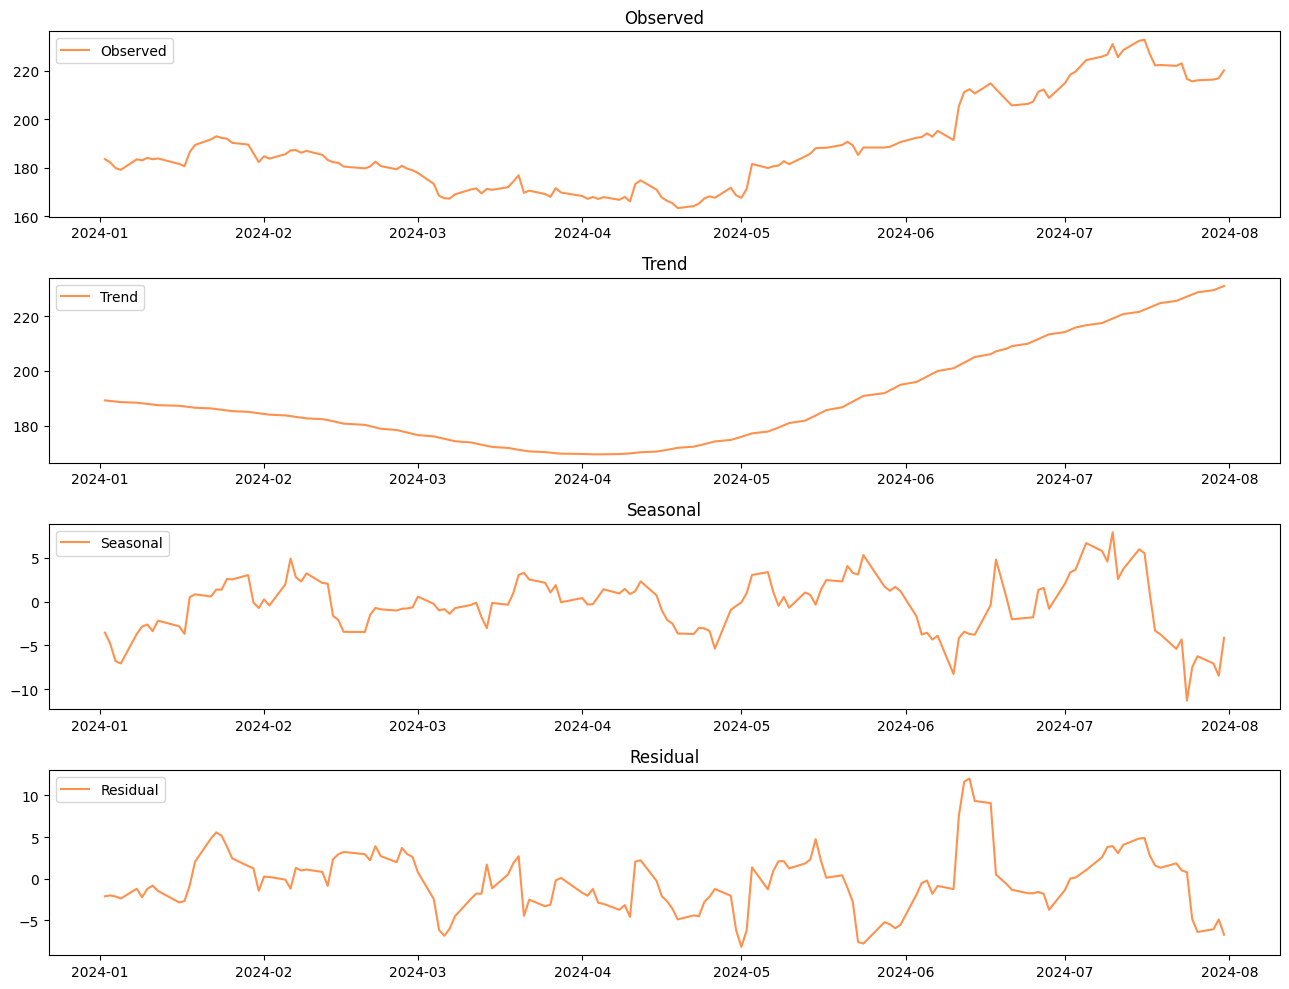

In [23]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(stock_data['Close'], period=30)
result = stl.fit()

fig, ax = plt.subplots(4, 1, figsize=(13, 10))

# Observed
ax[0].plot(result.observed, label='Observed', color='#FF914D')
ax[0].legend(loc='upper left')
ax[0].set_title("Observed")

# Trend
ax[1].plot(result.trend, label='Trend', color='#FF914D')
ax[1].legend(loc='upper left')
ax[1].set_title("Trend")

# Seasonal
ax[2].plot(result.seasonal, label='Seasonal', color='#FF914D')
ax[2].legend(loc='upper left')
ax[2].set_title("Seasonal")

# Residual
ax[3].plot(result.resid, label='Residual', color='#FF914D')
ax[3].legend(loc='upper left')
ax[3].set_title("Residual")

plt.tight_layout()
plt.show()

# 5. Stationarity

A time series is said to be **stationary** if its statistical properties such as **mean, variance, and autocorrelation** remain constant over time.

---

## Why Stationarity is Important

Stationarity is important because most forecasting models assume that the statistical properties of the data remain constant over time.

This is useful because:
- It simplifies modeling and analysis
- It improves the reliability of predictions
- It ensures models trained on past data remain valid for future forecasting

---

## Types of Stationarity

### 1. Weak Stationarity (Covariance Stationarity)

A time series is weakly stationary if:
- Mean is constant over time  
- Variance is constant over time  
- Autocorrelation depends only on lag (not on time itself)  
- The joint distribution may still change over time  

It is commonly used for short-term time series modeling.

---

### 2. Strict Stationarity

A time series is strictly stationary if:
- All statistical properties remain unchanged under time shifts  
- The entire joint distribution remains invariant when the series is shifted in time  

It is used for modeling the full distribution of the data.

In simple terms:
> Strict stationarity means the probabilistic structure of the series does not change over time.

It is a stronger condition than weak stationarity.

---

![Stationarity Example](./images/img2.png)  
![Stationarity Example](./images/img3.png)

---

# Tests for Weak Stationarity

## 1. Augmented Dickey-Fuller (ADF) Test

Used to check the presence of a **unit root**, which indicates non-stationarity (trend).

### Hypothesis:
- **H₀ (Null):** Data is non-stationary  
- **H₁ (Alternative):** Data is stationary  

### Decision Criteria:
- If **p-value < α (significance level)** → Reject H₀ → Data is stationary  
- If **ADF statistic < Critical value** → Reject H₀ → Data is stationary  

---

## 2. KPSS Test

KPSS assumes the data is stationary and tests for deviations from it.

It fits a constant mean model and examines the variance of the cumulative sum of residuals.

### Hypothesis:
- **H₀ (Null):** Data is stationary  
- **H₁ (Alternative):** Data is non-stationary  

### Interpretation:
- If p-value is small → reject H₀ → data is non-stationary  
- If p-value is large → fail to reject H₀ → data is stationary  

---

# Tests for Strict Stationarity

## Kolmogorov–Smirnov (KS) Test

The KS test compares the **cumulative distribution functions (CDFs)** of two samples.

It checks whether two samples come from the same distribution.

### Interpretation:
- If **p-value > 0.05** → no significant difference in distributions → data is considered strictly stationary  
- If **p-value ≤ 0.05** → distributions differ → not strictly stationary  

# ADF test

In [25]:
from statsmodels.tsa.stattools import adfuller

adf_test = adfuller(stock_data['Close'])

print("ADF Test Results:")
print(f"ADF Statistic : {round(adf_test[0], 3)}")
print(f"P-value : {round(adf_test[1], 3)}")

print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"{key} : {round(value, 3)}")

ADF Test Results:
ADF Statistic : -0.162
P-value : 0.943
Critical Values:
1% : -3.476
5% : -2.882
10% : -2.578


# KPSS test

In [30]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(stock_data['Close'], regression='ct')

print("KPSS Test Results:")
print(f"KPSS Statistic : {round(kpss_test[0], 3)}")
print(f"P-value : {round(kpss_test[1], 3)}")

print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"{key} : {round(value, 3)}")

KPSS Test Results:
KPSS Statistic : 0.399
P-value : 0.01
Critical Values:
10% : 0.119
5% : 0.146
2.5% : 0.176
1% : 0.216


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5452\196455983.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(stock_data['Close'], regression='ct')


# KS Test with Synthetic Data

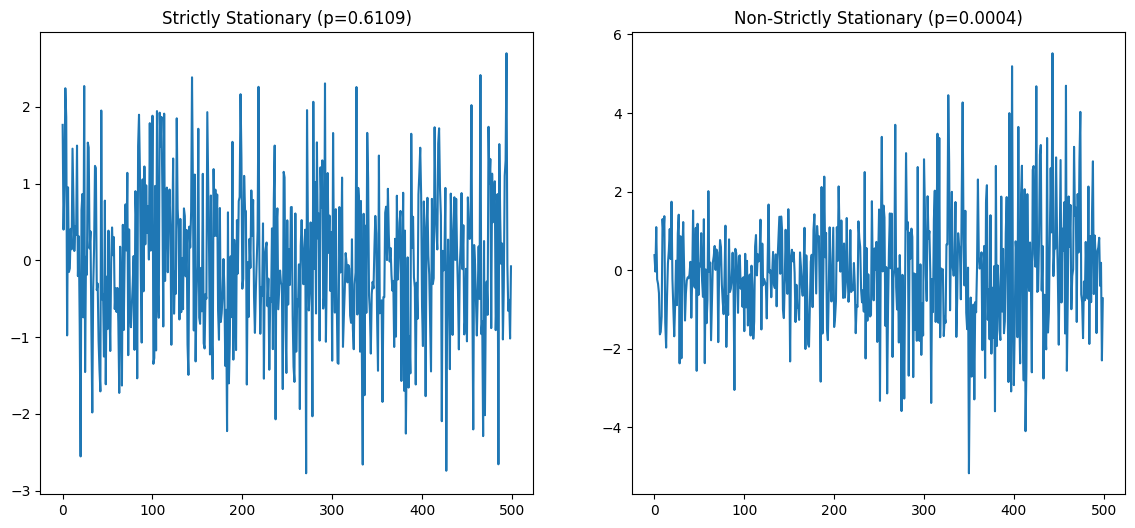

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# Generating synthetic data for demonstration
np.random.seed(0)
n = 500

# Strictly stationary series: normally distributed random noise
strict_stationary_series = np.random.normal(0, 1, n)

# Non-strictly stationary series: changing variance
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 1, n // 2),
    np.random.normal(0, 2, n // 2)
])

# Function to split the series into two halves and perform the K-S test
def ks_test_stationarity(series):
    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    stat, p_value = ks_2samp(series_first_half, series_second_half)
    return stat, p_value

# Perform the K-S test on strictly stationary series
ks_stat_strict, ks_pvalue_strict = ks_test_stationarity(strict_stationary_series)

# Perform the K-S test on non-strictly stationary series
ks_stat_non_strict, ks_pvalue_non_strict = ks_test_stationarity(non_strict_stationary_series)

# Plotting the series
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(strict_stationary_series)
plt.title(f"Strictly Stationary (p={ks_pvalue_strict:.4f})")

plt.subplot(1, 2, 2)
plt.plot(non_strict_stationary_series)
plt.title(f"Non-Strictly Stationary (p={ks_pvalue_non_strict:.4f})")
plt.show()

# Making a Time Series Data Stationary

To make a time series stationary, we apply transformations that remove trend, seasonality, and stabilize variance.

---

## Methods

## 1. Differencing

Differencing is used to remove trend and stabilize the mean by computing differences between consecutive observations.

### First-order differencing:
$y'_t = y_t - y_{t-1}$

### Second-order differencing:
Used if first-order differencing is not enough to achieve stationarity.

$y''_t = y'_t - y'_{t-1}$

### Seasonal differencing:
For seasonal data, we subtract the value from the same season in the previous cycle:

$y'_t = y_t - y_{t-s}$

(where $s$ is the seasonal period)

---

## 2. Transformation

Transformations are used to stabilize variance in the time series.

Common methods:

- **Log transformation**:  
  $y'_t = \log(y_t)$  
  Reduces large fluctuations and stabilizes variance.

- **Square root transformation**:  
  $y'_t = \sqrt{y_t}$

- **Box-Cox transformation**:  
  A flexible transformation that combines power and logarithmic transformations to stabilize variance more effectively.

---

## 3. Detrending

Detrending removes the trend component from the time series.

$y'_t = y_t - \text{trend}_t$

### Types of detrending:

- **Linear detrending**:  
  Removes a linear trend by fitting a straight line to the data and subtracting it.

- **Moving average detrending**:  
  Uses a sliding window average to estimate the trend and subtract it from the original series.

---

## 4. Seasonality Adjustment

Seasonality adjustment removes the seasonal component from the time series.

This helps isolate the underlying trend and irregular components by removing repeating seasonal patterns.

It is commonly done using:
- Seasonal differencing
- Seasonal decomposition methods (additive or multiplicative)

---

## Summary

To make a time series stationary, we typically:
- Remove trend → Differencing / Detrending  
- Stabilize variance → Transformations  
- Remove seasonality → Seasonal adjustment

# Differencing

In [33]:
#Functions to check KPSS and ADF for stationary
def adf_test(series):
    result = adfuller(series)

    print("ADF Statistics:", result[0])
    print("p-value:", result[1])

    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value:.3f}")

def kpss_test(series):
    result = kpss(series)

    print("KPSS Statistics:", result[0])
    print("p-value:", result[1])

    for key, value in result[3].items():
        print(f"Critical Value ({key}): {value:.3f}")

In [34]:
prices = stock_data['Close']

In [35]:
adf_test(prices)

ADF Statistics: -0.1618574512367323
p-value: 0.9429180114127478
Critical Value (1%): -3.476
Critical Value (5%): -2.882
Critical Value (10%): -2.578


In [36]:
prices

Date
2024-01-02    183.562195
2024-01-03    182.187759
2024-01-04    179.873932
2024-01-05    179.152100
2024-01-08    183.483063
                 ...    
2024-07-25    215.622192
2024-07-26    216.088135
2024-07-29    216.365738
2024-07-30    216.920944
2024-07-31    220.172760
Name: Close, Length: 146, dtype: float64

In [51]:
prices_diff = prices.diff()

In [53]:
adf_test(prices_diff.dropna())

ADF Statistics: -11.022786533137415
p-value: 5.929768699550062e-20
Critical Value (1%): -3.477
Critical Value (5%): -2.882
Critical Value (10%): -2.578


# Transformation

In [42]:
import numpy as np
from scipy import stats 

#Log Transform
prices_log = np.log(prices)

#Square root transform
prices_sqrt = np.sqrt(prices)

#Box-Cox transform
prices_box_cox, lam = stats.boxcox(prices[prices > 0])

In [48]:
adf_test(prices_log)

ADF Statistics: -0.21701343887482724
p-value: 0.936463042178489
Critical Value (1%): -3.476
Critical Value (5%): -2.882
Critical Value (10%): -2.578


In [47]:
adf_test(prices_sqrt)

ADF Statistics: -0.18651558065231919
p-value: 0.9401099535098125
Critical Value (1%): -3.476
Critical Value (5%): -2.882
Critical Value (10%): -2.578


In [46]:
adf_test(prices_box_cox)

ADF Statistics: -0.5742980732494111
p-value: 0.876684496080644
Critical Value (1%): -3.476
Critical Value (5%): -2.882
Critical Value (10%): -2.578


# Detrending

In [59]:
# Linear detrending
trend = np.polyfit(np.arange(len(prices)), prices , 1)
trend_line = np.polyval(trend, np.arange(len(prices)))
prices_detrended = prices - trend_line


In [60]:
adf_test(prices_detrended)

ADF Statistics: -1.378418409748926
p-value: 0.5925777643143211
Critical Value (1%): -3.476
Critical Value (5%): -2.882
Critical Value (10%): -2.578


In [61]:
# Moving average detrending 
window = 12
prices_ma = prices.rolling(window = window).mean()
prices_detrended = prices - prices_ma
prices_detrended = prices_detrended.dropna() 

In [62]:
adf_test(prices_detrended)

ADF Statistics: -2.8850239089460135
p-value: 0.047117435208640486
Critical Value (1%): -3.480
Critical Value (5%): -2.883
Critical Value (10%): -2.578


# Seasonality Adjustment

In [63]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(prices, model="additive", period=30)
prices_adjusted = prices / decomposition.seasonal
prices_adjusted = prices_adjusted.dropna()

In [64]:
adf_test(prices_adjusted)

ADF Statistics: -5.74643500166103
p-value: 6.106147521852643e-07
Critical Value (1%): -3.480
Critical Value (5%): -2.883
Critical Value (10%): -2.578


# White Noise and Random Walk

## 1. White Noise

White noise is a completely random time series with:
- No pattern
- No trend
- No seasonality

### Characteristics:
- Constant mean  
- Constant variance  
- No autocorrelation between observations  
- Fully random and unpredictable  

Mathematically:

$y_t \sim WN(0, \sigma^2)$

where:
- Mean = 0
- Variance = $\sigma^2$

White noise is often considered as the residual or error component in time series models.

---

## 2. Random Walk

A random walk is a time series where the current value depends on the previous value plus a random error.

\[
y_t = y_{t-1} + \epsilon_t
\]

where:
- $y_t$ = current value  
- $y_{t-1}$ = previous value  
- $\epsilon_t$ = white noise error term  

### Characteristics:
- Shows cumulative behavior over time  
- Non-stationary in nature  
- Future values are influenced by past values  
- Commonly observed in stock prices and financial markets  

Although random walks appear to have trends, they are largely driven by accumulated random shocks.

---

![White Noise and Random Walk](./images/img4.png)

---

# Identifying White Noise and Random Walk

## 1. Visual Inspection

Plot the time series and observe:
- Presence of trend
- Seasonality
- Random fluctuations

White noise appears completely random, while random walk shows drifting behavior over time.

---

## 2. ACF and PACF Plots

### White Noise:
- ACF values quickly drop to zero  
- No significant autocorrelation  
- PACF also shows no significant lags  

### Random Walk:
- ACF decreases slowly  
- Strong autocorrelation exists  
- Indicates non-stationarity  

---

## 3. Ljung-Box Test

The Ljung-Box test checks whether autocorrelation exists in the series.

### Hypothesis:
- $H_0$: Data is independently distributed (white noise)  
- $H_1$: Data contains autocorrelation  

### Interpretation:
- If p-value > 0.05 → Fail to reject $H_0$ → Data behaves like white noise  
- If p-value ≤ 0.05 → Reject $H_0$ → Autocorrelation exists  

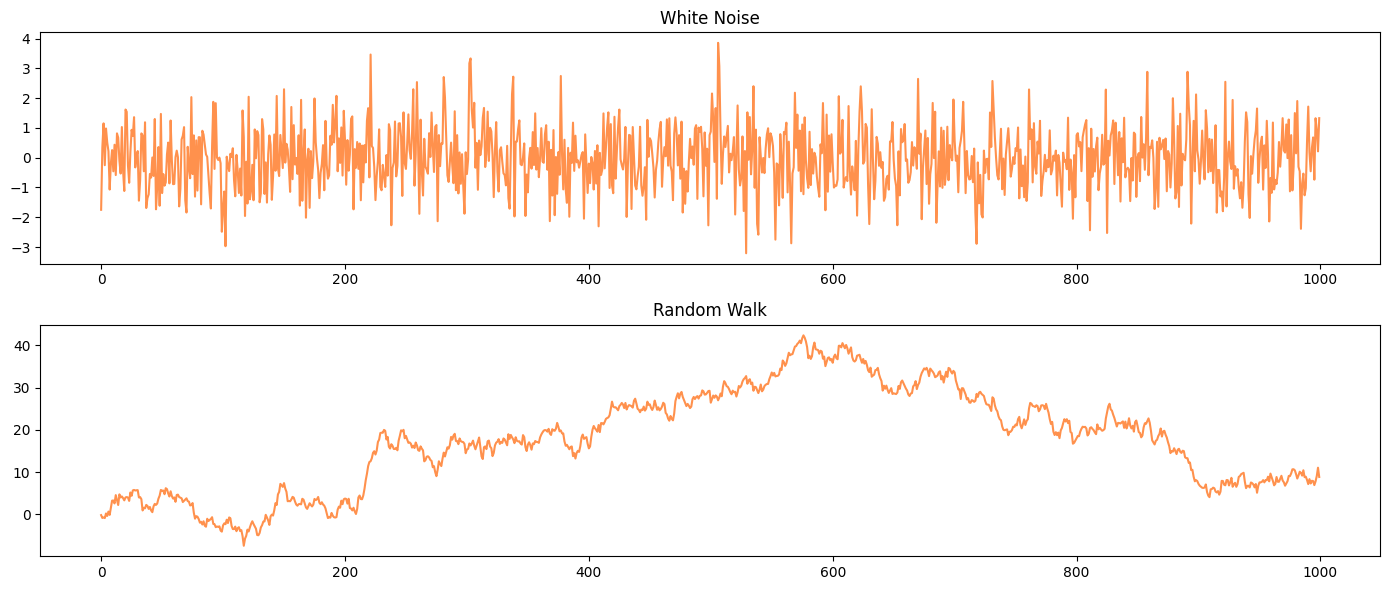

In [67]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(100)

n = 1000

# White noise
white_noise = np.random.normal(0, 1, n)

# Random walk
random_shocks = np.random.normal(0, 1, n)
random_walk = np.cumsum(random_shocks)

# Plotting the series
fig, ax = plt.subplots(2, 1, figsize=(14, 6))

# White noise plot
ax[0].plot(white_noise, color="#FF914D")
ax[0].set_title("White Noise")

# Random walk plot
ax[1].plot(random_walk, color="#FF914D")
ax[1].set_title("Random Walk")

plt.tight_layout()
plt.show()

In [68]:
#Ljung-Box Test
print(f"\nLjung Box Test for white noise")
lb_test_white_noise = acorr_ljungbox(white_noise ,  lags = [10], return_df= True)
print(lb_test_white_noise)

print(f"\nLjung Box Test for random walk")
lb_test_random_walk = acorr_ljungbox(random_walk,  lags = [10], return_df= True)
print(lb_test_random_walk)


Ljung Box Test for white noise
      lb_stat  lb_pvalue
10  10.518418   0.396246

Ljung Box Test for random walk
        lb_stat  lb_pvalue
10  9547.898055        0.0
